Enhancement: ['Gaussian blur (5, 5)']

=== Detection Result ===
Alligator detected: True
Affected area: 30883 pixels  (7.6% of image)


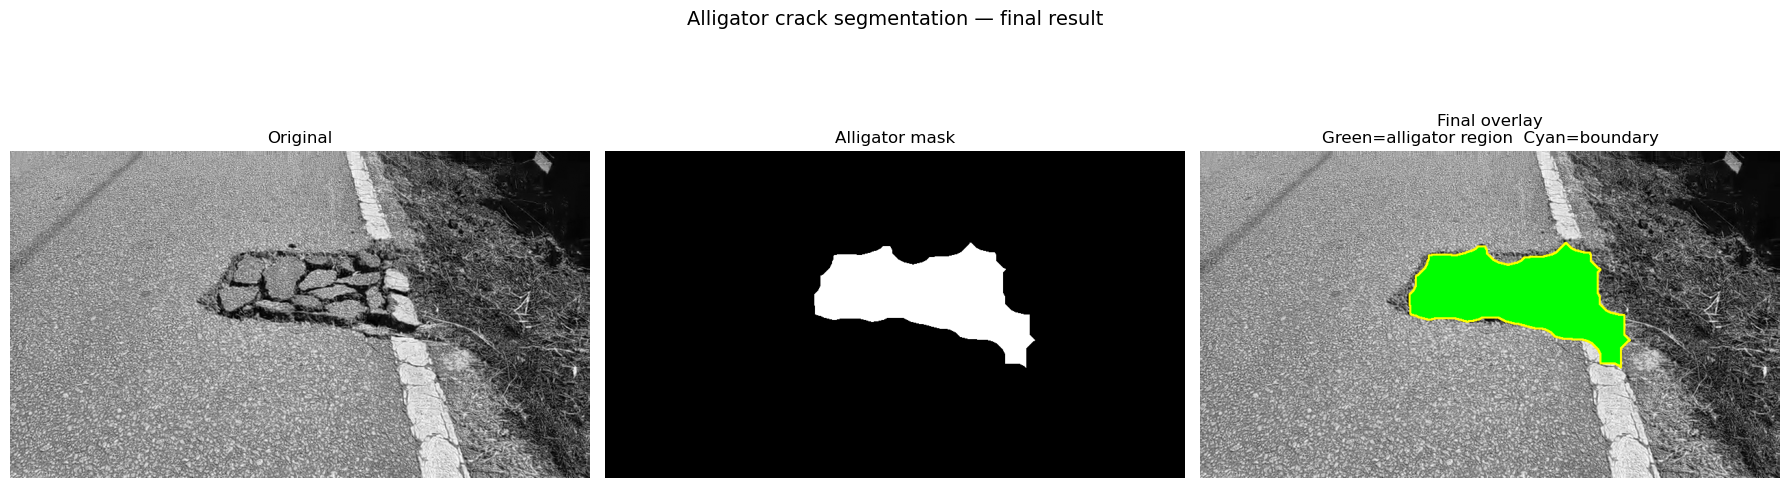

In [10]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def estimate_blur(image, threshold=200):
    laplacian = cv2.Laplacian(image, cv2.CV_64F)
    variance = laplacian.var()
    return variance, variance < threshold

def estimate_noise(image):
    blurred = cv2.GaussianBlur(image, (5, 5), 1.5)
    diff = cv2.absdiff(image, blurred)
    noise_level = np.mean(diff)
    return noise_level, noise_level > 10

def estimate_contrast(image):
    std_dev = np.std(image)
    hist = cv2.calcHist([image], [0], None, [256], [0, 256])
    non_zero = np.where(hist > 0)[0]
    spread = non_zero[-1] - non_zero[0] if len(non_zero) > 0 else 0
    low_contrast = (std_dev < 40) or (spread < 150)
    return std_dev, spread, low_contrast

def dynamic_preprocess(image):
    steps_applied = []
    processed = image.copy()
    blur_value, is_blurry = estimate_blur(image)
    if is_blurry:
        kernel = np.array([[-1,-1,-1], [-1, 9,-1], [-1,-1,-1]])
        processed = cv2.filter2D(processed, -1, kernel)
        steps_applied.append("Sharpening")
    noise_level, is_noisy = estimate_noise(processed)
    if is_noisy:
        kernel_size = (7,7) if noise_level > 20 else (5,5) if noise_level > 15 else (3,3)
        processed = cv2.GaussianBlur(processed, kernel_size, 1.0)
        steps_applied.append(f"Gaussian blur {kernel_size}")
    std_dev, spread, low_contrast = estimate_contrast(processed)
    if low_contrast:
        clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
        processed = clahe.apply(processed)
        steps_applied.append("CLAHE equalization")
    return processed, steps_applied

def segment_alligator(image):
    # Step 1: Blur to suppress road grain
    blurred = cv2.GaussianBlur(image, (5, 5), 0)

    # Step 2: Blackhat — finds dark patch on bright road
    kernel_bh = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (25, 25))
    blackhat = cv2.morphologyEx(blurred, cv2.MORPH_BLACKHAT, kernel_bh)

    # Step 3: Threshold — tuned from debug session
    _, binary = cv2.threshold(blackhat, 85, 255, cv2.THRESH_BINARY)

    # Step 4: Close gaps inside the patch
    kernel_close = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (20, 20))
    closed = cv2.morphologyEx(binary, cv2.MORPH_CLOSE, kernel_close, iterations=3)

    # Step 5: Shape filter — keep only real alligator patch
    contours, _ = cv2.findContours(closed, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    mask = np.zeros_like(closed)
    for cnt in contours:
        area = cv2.contourArea(cnt)
        if area < 8000:          # raised from 3000 — removes small false blob
            continue
        x, y, w, h = cv2.boundingRect(cnt)
        aspect = w / float(h) if h > 0 else 0
        hull_area = cv2.contourArea(cv2.convexHull(cnt))
        solidity = area / hull_area if hull_area > 0 else 0
        if (0.3 < aspect < 4.0) and (solidity > 0.4):
            cv2.drawContours(mask, [cnt], -1, 255, -1)

    return mask

# ===== Run =====
path = "C:/Users/USER/Desktop/image processing project/image processing video/alligator/extracted/85.jpg"
img = cv2.imread(path, 0)
enhanced, steps = dynamic_preprocess(img)
print(f"Enhancement: {steps}")

mask = segment_alligator(enhanced)

# Create colored overlay
overlay = cv2.cvtColor(img, cv2.COLOR_GRAY2BGR)
overlay[mask > 0] = [0, 255, 0]  # green = alligator

# Also draw contour outline
contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
cv2.drawContours(overlay, contours, -1, (0, 255, 255), 2)  # cyan border

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
axes[0].imshow(img,     cmap='gray')
axes[0].set_title("Original")
axes[0].axis('off')

axes[1].imshow(mask,    cmap='gray')
axes[1].set_title("Alligator mask")
axes[1].axis('off')

axes[2].imshow(cv2.cvtColor(overlay, cv2.COLOR_BGR2RGB))
axes[2].set_title("Final overlay\nGreen=alligator region  Cyan=boundary")
axes[2].axis('off')

# Print detection summary
detected = np.any(mask)
area_px = np.sum(mask == 255)
print(f"\n=== Detection Result ===")
print(f"Alligator detected: {detected}")
print(f"Affected area: {area_px} pixels  ({100*area_px/(img.shape[0]*img.shape[1]):.1f}% of image)")

plt.suptitle("Alligator crack segmentation — final result", fontsize=14)
plt.tight_layout()
plt.show()

In [7]:
# ===== ROI EXTRACTION =====
contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

if contours:
    # Get bounding box of the largest contour
    largest = max(contours, key=cv2.contourArea)
    x, y, w, h = cv2.boundingRect(largest)

    # Add padding around the ROI
    pad = 20
    x1 = max(0, x - pad)
    y1 = max(0, y - pad)
    x2 = min(img.shape[1], x + w + pad)
    y2 = min(img.shape[0], y + h + pad)

    # Crop ROI from original and enhanced
    roi_original = img[y1:y2, x1:x2]
    roi_enhanced = enhanced[y1:y2, x1:x2]
    roi_mask     = mask[y1:y2, x1:x2]

    # Masked ROI — only the alligator region, background blacked out
    roi_masked = cv2.bitwise_and(roi_enhanced, roi_enhanced, mask=roi_mask)

    # Draw bounding box on overlay
    cv2.rectangle(overlay, (x1, y1), (x2, y2), (0, 165, 255), 2)  # orange box

    fig2, axes2 = plt.subplots(1, 4, figsize=(20, 5))

    axes2[0].imshow(cv2.cvtColor(overlay, cv2.COLOR_BGR2RGB))
    axes2[0].set_title("Full image\nOrange box = ROI location")
    axes2[0].axis('off')

    axes2[1].imshow(roi_original, cmap='gray')
    axes2[1].set_title(f"ROI — Original\n({w}x{h} px)")
    axes2[1].axis('off')

    axes2[2].imshow(roi_enhanced, cmap='gray')
    axes2[2].set_title("ROI — Enhanced")
    axes2[2].axis('off')

    axes2[3].imshow(roi_masked, cmap='gray')
    axes2[3].set_title("ROI — Masked\n(only alligator pixels)")
    axes2[3].axis('off')

    plt.suptitle("Alligator ROI Extraction", fontsize=14)
    plt.tight_layout()
    plt.show()

    print(f"\n=== ROI Info ===")
    print(f"Location: x={x1}, y={y1}")
    print(f"Size: {x2-x1} x {y2-y1} pixels")
    print(f"Alligator area: {np.sum(roi_mask==255)} pixels")

else:
    print("No alligator region detected.")

No alligator region detected.
